In [2]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
#@save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

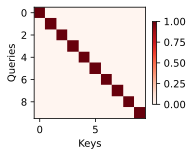

In [4]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

In [5]:
print("attention_weights", attention_weights)

attention_weights tensor([[[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]]])


真实规律是 f(x)。x_train 是采样点，y_train = f(x_train) + 噪声 是对真实规律的带噪观测。y_truth = f(x_test) 是测试点上的无噪真值。目标是用 (x_train, y_train) 通过注意力池化（核回归）对 x_test 做预测，使预测值 y_hat 尽量接近 y_truth，从而验证模型学到了真实规律 f 而非过拟合噪声。

In [ ]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本。 torch.rand返回(0,1]之间的随机数

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

In [7]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

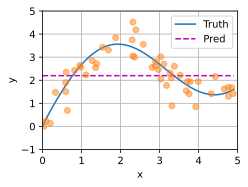

In [8]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

注意力的本质是判断目标对其他对象的注意力程度，或者反之目标受其他对象的影响程度
令 $w_{ik} = \frac{\alpha(x_i, x_k)}{\sum_{j=1}^{n} \alpha(x_i, x_j)} $,表示$x_k$对$x_i$的影响是整体影响的多少分之一
则 $\hat{y}_i = \sum_{j=1}^{n} w_{ij} \cdot y_j$ ，表示$\hat{y}_i$根据$x_i$收到$x_k$的影响来使用各种$y_k$合成的值应该是多少

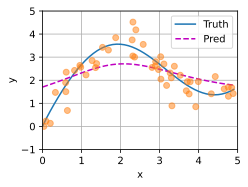

In [ ]:

def alpha(a_x_train, a_x_test):
    scores = -(a_x_train - a_x_test)**2/2
    return torch.exp(scores)


y_preds = []

for a_x_test in x_test:
    y_pred = 0
    scores = []

    for a_x_train in x_train:
        score = alpha(a_x_train, a_x_test)
        scores.append(score)
    score_sum = sum(scores)

    y_pred = 0
    for score, a_y_train in zip(scores, y_train):
        y_pred += score/score_sum*a_y_train
    y_preds.append(y_pred)

plot_kernel_reg(y_preds)



X_repeat: torch.Size([50, 50])
x_train: torch.Size([50])
diff: torch.Size([50, 50])
attention_weights: torch.Size([50, 50])


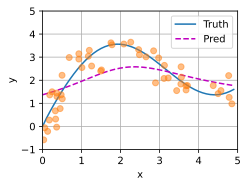

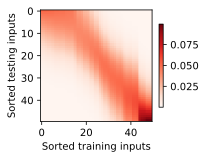

In [ ]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
print("X_repeat:",X_repeat.shape)
print("x_train:",x_train.shape)
diff = -(X_repeat - x_train)**2 / 2
print("diff:",diff.shape)
# print(diff)
attention_weights = nn.functional.softmax(input=diff, dim=1)
print("attention_weights:",attention_weights.shape)
# 注意矩阵相乘的顺序， attention的dim1表示 每个train对当前test对影响，attention_weights*y_train就表示当前x_test收到的加权影响
# y_train*attention_weights则完全不对
y_preds = torch.matmul(attention_weights, y_train) 
print("y_preds:",y_preds)
plot_kernel_reg(y_preds)
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

In [ ]:
# 将Nadaraya-Watson核改成带参数，所谓带参数就是指这个参数可以被训练
                 